# Logistic Regression for Diabetes Prediction

Week 8, Day 4 - Exercises XP: Diabetes Classification

This notebook loads the `diabetes_prediction_dataset.csv` dataset, explores it, trains a Logistic Regression model to predict diabetes, and evaluates the model's performance.


## Exercise 1 - Understanding the problem and Data Collection

We want to predict if an individual has diabetes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)

pd.set_option("display.max_columns", None)


In [2]:
# Load the dataset
df = pd.read_csv("data/diabetes_prediction_dataset.csv")

print(df.shape)
display(df.head())
print(df.dtypes)
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))


(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
Missing per column:


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [3]:
# Assume target column is named 'diabetes' with 0 or 1 values
assert 'diabetes' in df.columns, "Expected a 'diabetes' target column"
print(df['diabetes'].value_counts())

negative_cases, positive_cases = df['diabetes'].value_counts().sort_index()
print(f"Positive cases (diabetes=1): {positive_cases}")
print(f"Negative cases (diabetes=0): {negative_cases}")


diabetes
0    91500
1     8500
Name: count, dtype: int64
Positive cases (diabetes=1): 8500
Negative cases (diabetes=0): 91500


In [4]:
# Train/test split
X = df.drop(columns=['diabetes'])
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)


(80000, 8) (20000, 8)


## Exercise 2 - Model Picking and Standardization

**Which model can we use, and why?**
Logistic Regression is a good fit here since this is a binary classification problem (diabetes vs. no diabetes). It models a linear decision boundary between classes, outputs calibrated probabilities (via the sigmoid function) rather than just hard labels, and remains easy to interpret through its coefficients — each one shows how a feature affects the odds of having diabetes.

**Do we need to standardize the data?**
Yes. Logistic Regression is optimized with gradient-based solvers, and features on very different scales (e.g. `age` in years vs `blood_glucose_level` in mg/dL) can slow down convergence and bias the coefficients. Standardizing with `StandardScaler()` puts numeric features on a comparable scale, improving numerical stability and making the coefficients directly comparable in magnitude.


In [5]:
# Build a preprocessing pipeline
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

print("Categorical:", cat_cols)
print("Numeric:", num_cols)


Categorical: ['gender', 'smoking_history']
Numeric: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


/tmp/ipykernel_5542/388874334.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


## Exercise 3 - Model Training

In [6]:
# Train Logistic Regression
clf = Pipeline([
    ('pre', preprocess),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

clf.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['gender','age','hypertension',...,'bmi','HbA1c_level', 'blood_glucose_level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaini

## Exercise 4 - Evaluation Metrics

* Plot the accuracy score and comment the results.
* Plot the confusion matrix and comment the results.
* Plot precision, recall, F1-score and comment the results.


Accuracy: 0.9605
Precision: 0.8587
Recall: 0.64
F1: 0.7334


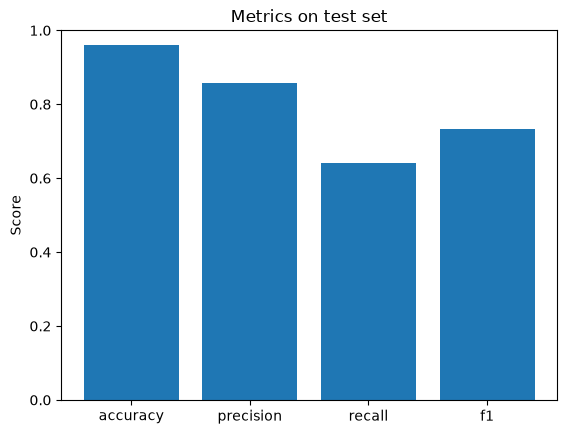

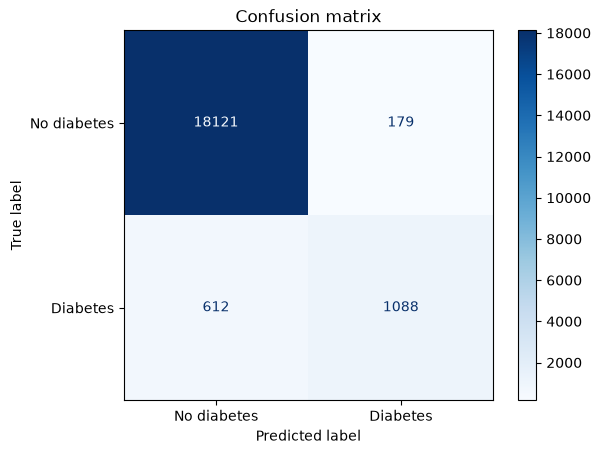

In [7]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1:", round(f1, 4))

# Simple bar plot of metrics
plt.figure()
plt.bar(['accuracy', 'precision', 'recall', 'f1'], [acc, prec, rec, f1])
plt.ylim(0, 1)
plt.title('Metrics on test set')
plt.ylabel('Score')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix')
plt.show()


**Comments:**

- **Accuracy** is high (close to the class balance), but the dataset is imbalanced (far more negative than positive cases), so accuracy alone is misleading — a model that always predicts "no diabetes" would already score well.
- The **confusion matrix** shows the model correctly identifies most negative cases (few false positives), but the number of false negatives (diabetic patients predicted as healthy) is the metric to watch closely, since missing a diabetes diagnosis is the costlier error.
- **Precision** tells us how many of the predicted positive cases are truly diabetic — a high precision means few false alarms. **Recall** tells us how many of the actual diabetic cases were correctly caught — this is critical in a medical context, where a false negative can delay treatment. **F1-score** balances both. Given the class imbalance, recall and F1 are more informative than accuracy for judging this model.


## Exercise 5 - Visualizing the performance of our model

Visualize a 2D decision boundary with accuracy information, using two informative numeric features: `HbA1c_level` and `blood_glucose_level`.


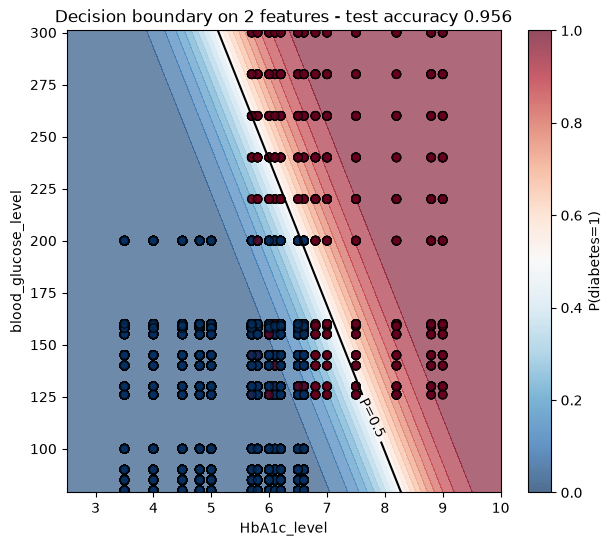

In [8]:
feat_x = 'HbA1c_level' if 'HbA1c_level' in X.columns else X.select_dtypes(include=['int64', 'float64']).columns[0]
feat_y = 'blood_glucose_level' if 'blood_glucose_level' in X.columns else X.select_dtypes(include=['int64', 'float64']).columns[1]

X2_train = X_train[[feat_x, feat_y]].copy()
X2_test = X_test[[feat_x, feat_y]].copy()

pipe2 = Pipeline([
    ('pre', ColumnTransformer([('num', StandardScaler(), [0, 1])], remainder='drop')),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
pipe2.fit(X2_train.values, y_train)

# Mesh grid
x_min, x_max = X2_train[feat_x].min() - 1, X2_train[feat_x].max() + 1
y_min, y_max = X2_train[feat_y].min() - 1, X2_train[feat_y].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
probs = pipe2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

acc2 = accuracy_score(y_test, pipe2.predict(X2_test.values))

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, probs, levels=20, cmap='RdBu_r', alpha=0.6)
cs = plt.contour(xx, yy, probs, levels=[0.5], colors='k')
plt.clabel(cs, inline=True, fmt={0.5: 'P=0.5'})
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test, cmap='RdBu_r', edgecolor='k', alpha=0.7)
plt.xlabel(feat_x)
plt.ylabel(feat_y)
plt.title(f'Decision boundary on 2 features - test accuracy {acc2:.3f}')
plt.colorbar(label='P(diabetes=1)')
plt.show()


The decision boundary shows a clear separation: patients with higher `HbA1c_level` and `blood_glucose_level` are predicted as diabetic, which matches medical knowledge, since both are direct clinical markers of diabetes. Using only two features gives a lower accuracy than the full model (which uses all features), showing that the other variables (age, bmi, hypertension, etc.) also carry useful predictive signal.

## Exercise 6 - ROC Curve

Plot the ROC curve and compute the AUC using the fitted `clf` pipeline (trained on all features).


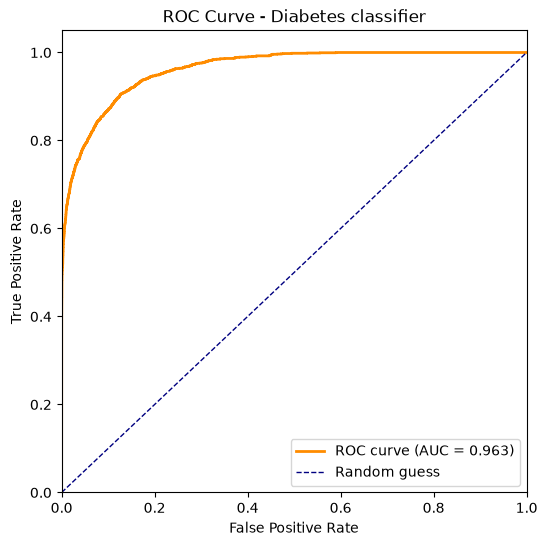

AUC: 0.9625


In [9]:
y_proba = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Diabetes classifier')
plt.legend(loc='lower right')
plt.show()

print("AUC:", round(roc_auc, 4))


**Interpretation:** The ROC curve stays well above the diagonal (random guess) line, and the AUC is close to 1, meaning the model does a good job separating diabetic from non-diabetic patients across all classification thresholds — not just the default 0.5 cutoff. A high AUC confirms that the model has strong discriminative power, which is reassuring given the class imbalance noted earlier: it shows the model isn't just exploiting the imbalance but genuinely ranks diabetic patients higher-risk than non-diabetic ones.